In [1]:
# Imports for t-SNE analysis
from data_preprocessing import split_data,standardize_dates, add_days_to_floraison, NIRS_INDEXES, NIRS_INDEXES_INT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap

/home/dodo/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load and preprocess data

data = pd.read_csv("./Data/CIRAD_Sorghum2023_SPIR_all_2 (4).csv", sep=";")
data = standardize_dates(data)
data = add_days_to_floraison(data)
data.head()

,Genotype,Sample,ID,Date_Floraison,Date_SPIR,Traitement,Rep,Position,350,351,...,2492,2493,2494,2495,2496,2497,2498,2499,2500,Dates_Delta
0,Btx623,FreshLeaf,117,2023-05-19,2023-06-01,C,1,FlagLeaf,0.075652,0.070583,...,0.085991,0.085268,0.084832,0.084246,0.083982,0.083914,0.083658,0.083273,0.083111,13
1,Btx623,FreshLeaf,117,2023-05-19,2023-06-01,C,2,FlagLeaf,0.083377,0.082926,...,0.101342,0.101169,0.100833,0.100403,0.100057,0.099492,0.099523,0.099310,0.099126,13
2,Macia,FreshLeaf,203,2023-05-23,2023-06-01,SS2,1,FlagLeaf,0.078272,0.075389,...,0.078159,0.078018,0.077781,0.077200,0.077168,0.077273,0.077200,0.077064,0.076751,9
3,Macia,FreshLeaf,203,2023-05-23,2023-06-01,SS2,2,FlagLeaf,0.075764,0.074639,...,0.078284,0.078045,0.077868,0.077812,0.077722,0.077669,0.077620,0.077650,0.077399,9
4,Macia,FreshLeaf,215,2023-05-24,2023-06-01,C,1,FlagLeaf,0.061362,0.060504,...,0.068550,0.068382,0.068200,0.068012,0.067757,0.067621,0.067635,0.067188,0.067004,8


In [22]:
# Prepare spectral matrix and scale

X = data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)

# run t-SNE in 2 dimensions

tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE shape", X_tsne.shape)


t-SNE shape (2174, 2)


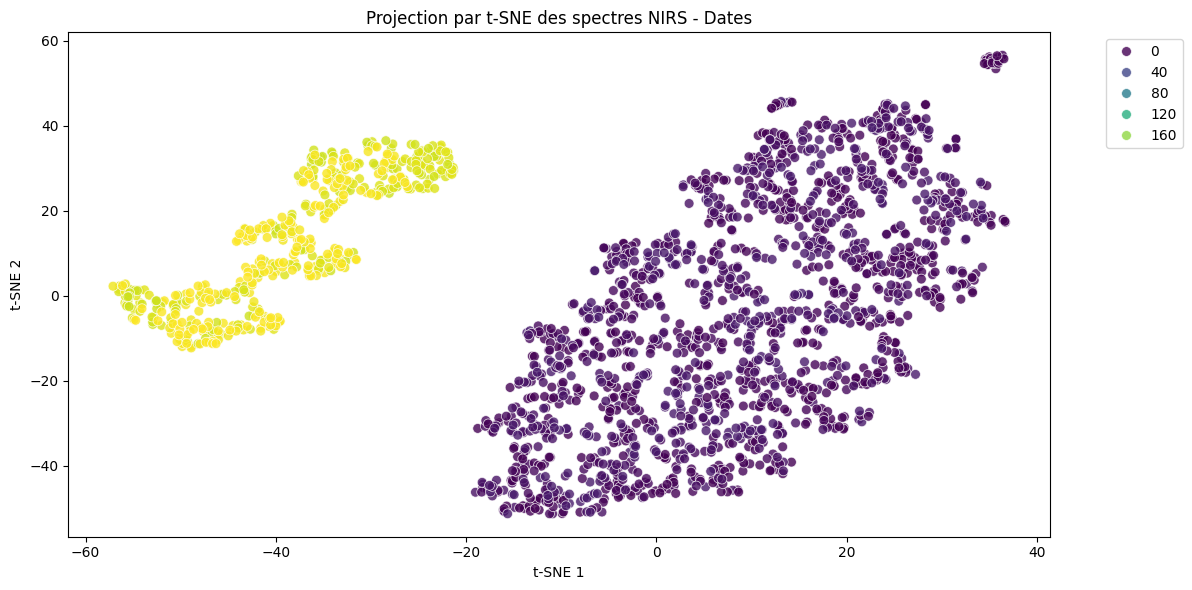

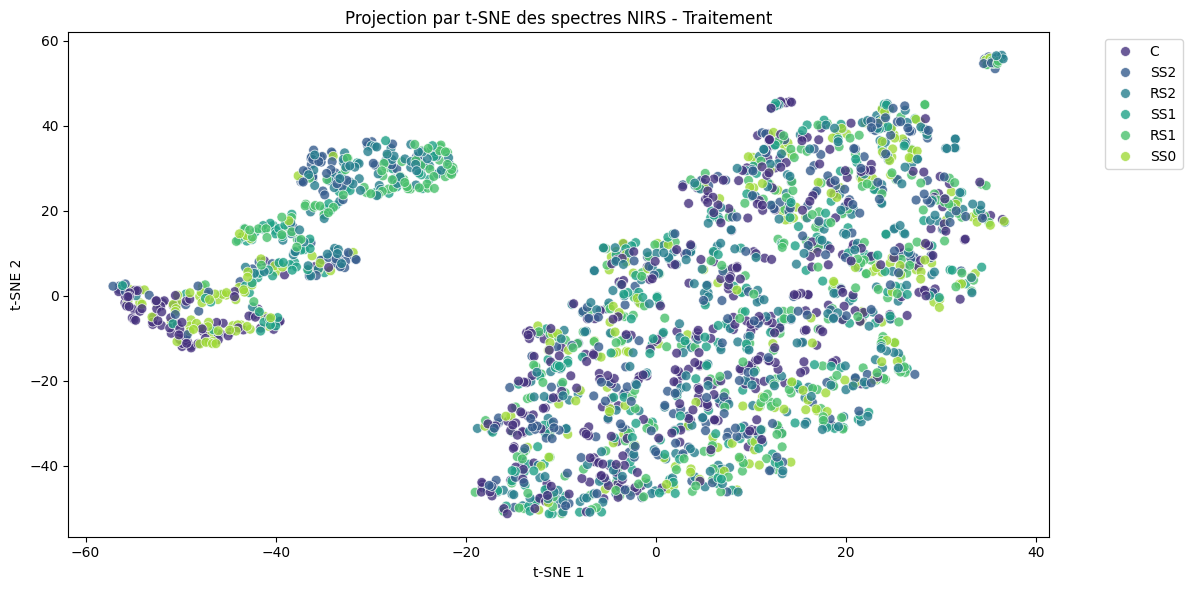

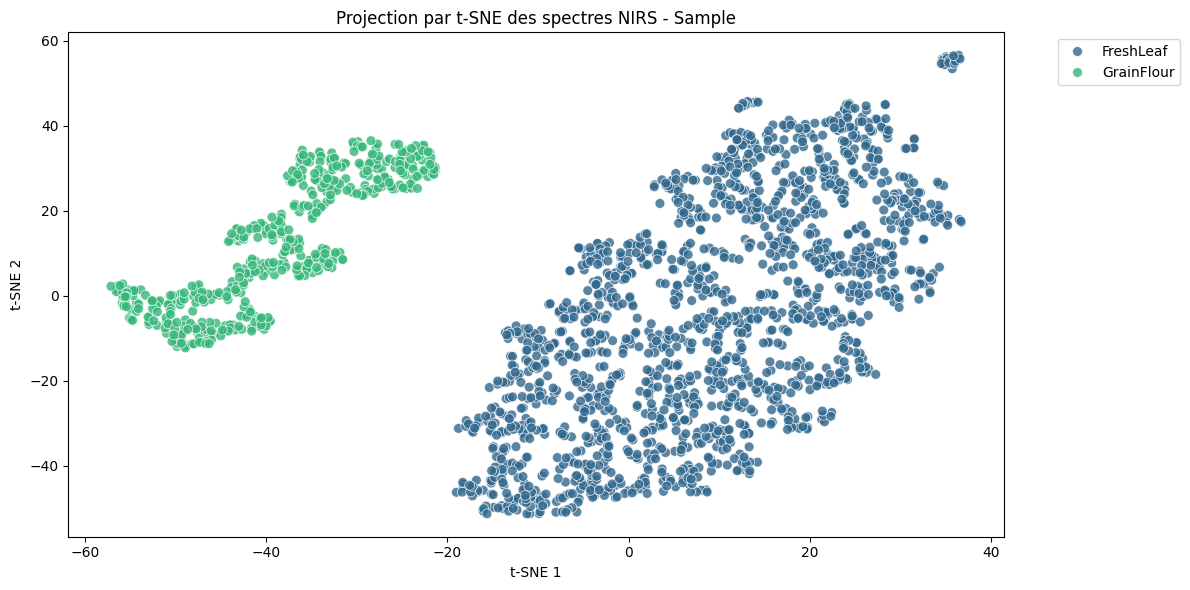

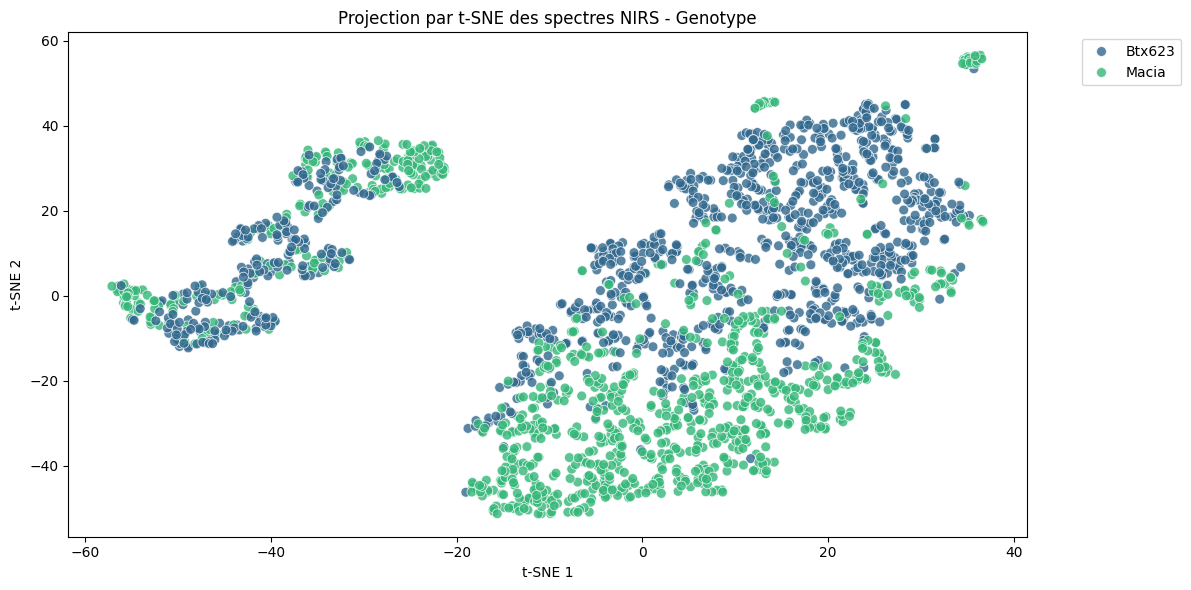

In [23]:
def plot_tsne(db,label_name, title=None, palette='viridis'):
    df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    df[label_name] = db[label_name].values
    plt.figure(figsize=(12,6))
    sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue=label_name,
                    palette=palette, s=50, alpha=0.8)
    plt.title(title or f"t-SNE colored by {label_name}")
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_UMAP_default(db,X_umap, label_name, tit):
    """plot en UMPAS par défaut"""
    fig, axe = plt.subplots(figsize=(12, 6))
    colors = db[label_name].astype('category').cat.codes
    axe.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, cmap='viridis', s=50, alpha=0.7)
    axe.set_title('UMAP')
    axe.set_xlabel('UMAP 1')
    axe.set_ylabel('UMAP 2')
    axe.grid(alpha=0.3)
    labels_unique = db[label_name].unique()
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=plt.cm.viridis(i/len(labels_unique)), 
                            markersize=10, label=lbl) 
                for i, lbl in enumerate(labels_unique)]
    axe.legend(handles=handles, loc='center right', title='Traitement')
        
    plt.tight_layout()
    plt.show()

#premiers plot comme ACP
title_base = "Projection par t-SNE des spectres NIRS"
plot_tsne(data,'Dates_Delta', title=title_base + ' - Dates')
plot_tsne(data,'Traitement', title=title_base + ' - Traitement')
plot_tsne(data,'Sample', title=title_base + ' - Sample')
plot_tsne(data,'Genotype', title=title_base + ' - Genotype')


On en est au point précédent de l'ACP ou toutes les donées sont mise y ccompris les différents génotype, le sample ce qui est pas satisfaisant
Découpons tout cela 

In [5]:
groups = split_data(data)

btx_leaf_data = groups[("Btx623","FreshLeaf")]

btx_grain_data = groups[("Btx623","GrainFlour")]

macia_leaf_data = groups[("Macia","FreshLeaf")]

macia_grain_data = groups[("Macia","GrainFlour")]

In [28]:

# Prepare spectral matrix and scale
X = macia_leaf_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)


# Calculer une perplexity adaptée
n_samples = len(macia_leaf_data)
recommended_perplexity = min(30, max(5, n_samples // 3))
print(f"Perplexity recommandée pour {n_samples} échantillons : {recommended_perplexity}")

# run t-SNE avec paramètres adaptés
tsne = TSNE(n_components=2, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

print(f"\nt-SNE shape : {X_tsne.shape}")

# UMAP avec min_dist élevé pour mieux espacer les points
reducer = umap.UMAP(random_state=42, min_dist=1, spread=2, n_neighbors=15)
X_umap = reducer.fit_transform(X_scaled)

Perplexity recommandée pour 806 échantillons : 30
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 806 samples in 0.011s...
[t-SNE] Computed neighbors for 806 samples in 0.053s...
[t-SNE] Computed conditional probabilities for sample 806 / 806
[t-SNE] Mean sigma: 4.215587
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.670685
[t-SNE] KL divergence after 2300 iterations: 0.755210

t-SNE shape : (806, 2)


/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


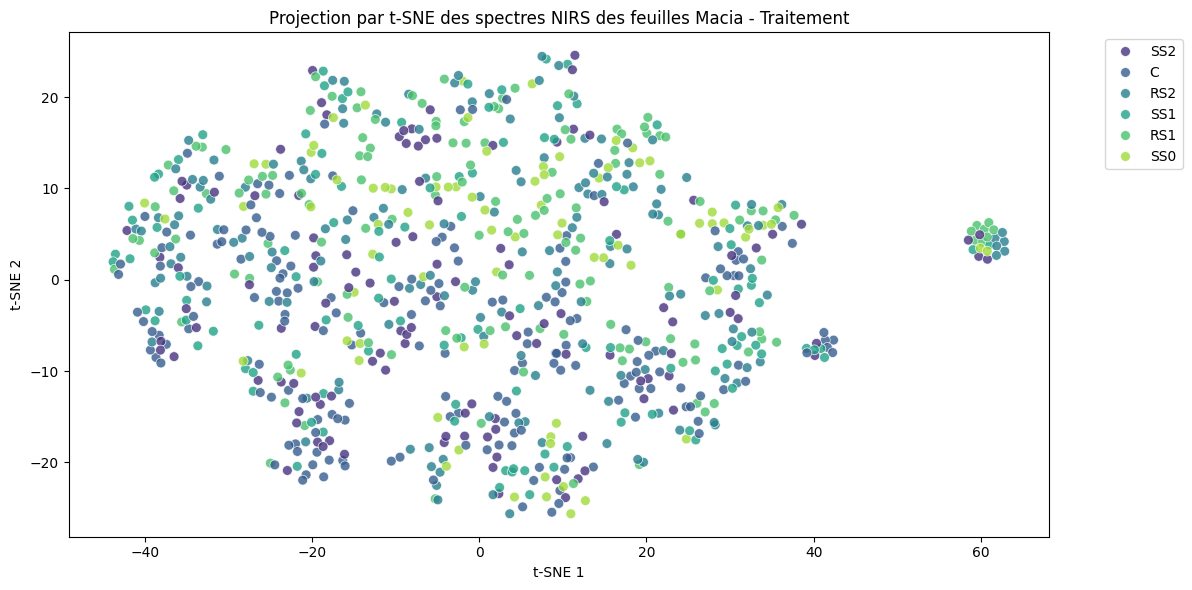

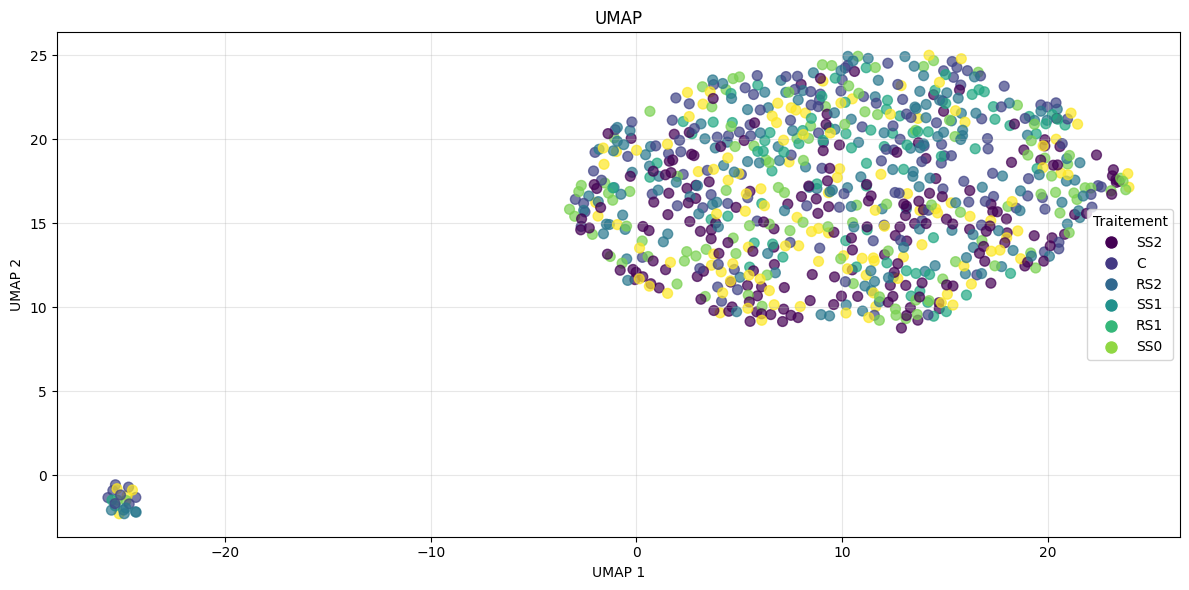

In [29]:


title_base = "Projection par t-SNE des spectres NIRS des feuilles Macia"
plot_tsne(macia_leaf_data,'Traitement', title=title_base + ' - Traitement')
plot_UMAP_default(macia_leaf_data,X_umap,'Traitement', '')



In [30]:

# Prepare spectral matrix and scale
X = btx_leaf_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)


# Calculer une perplexity adaptée
n_samples = len(btx_leaf_data)
recommended_perplexity = min(30, max(5, n_samples // 3))

# run t-SNE avec paramètres adaptés
tsne = TSNE(n_components=2, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

print(f"\nt-SNE shape : {X_tsne.shape}")

# UMAP avec min_dist élevé pour mieux espacer les points
reducer = umap.UMAP(random_state=42, min_dist=1, spread=2, n_neighbors=15)
X_umap = reducer.fit_transform(X_scaled)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 892 samples in 0.009s...
[t-SNE] Computed neighbors for 892 samples in 0.042s...
[t-SNE] Computed conditional probabilities for sample 892 / 892
[t-SNE] Mean sigma: 8.577908
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.794025
[t-SNE] KL divergence after 3000 iterations: 0.820088

t-SNE shape : (892, 2)


/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


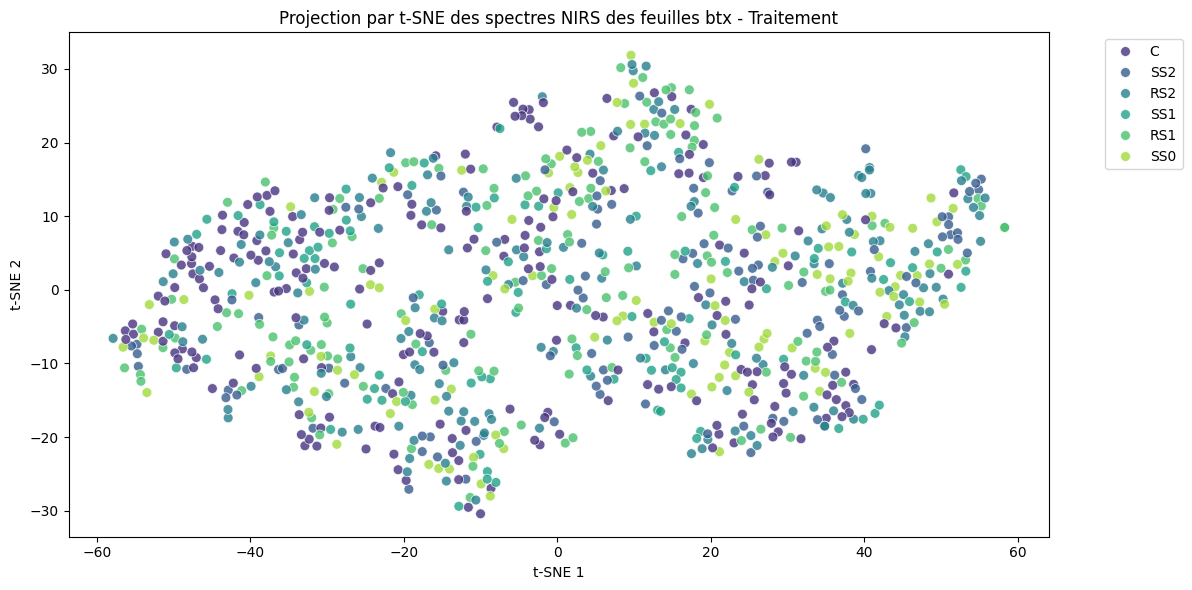

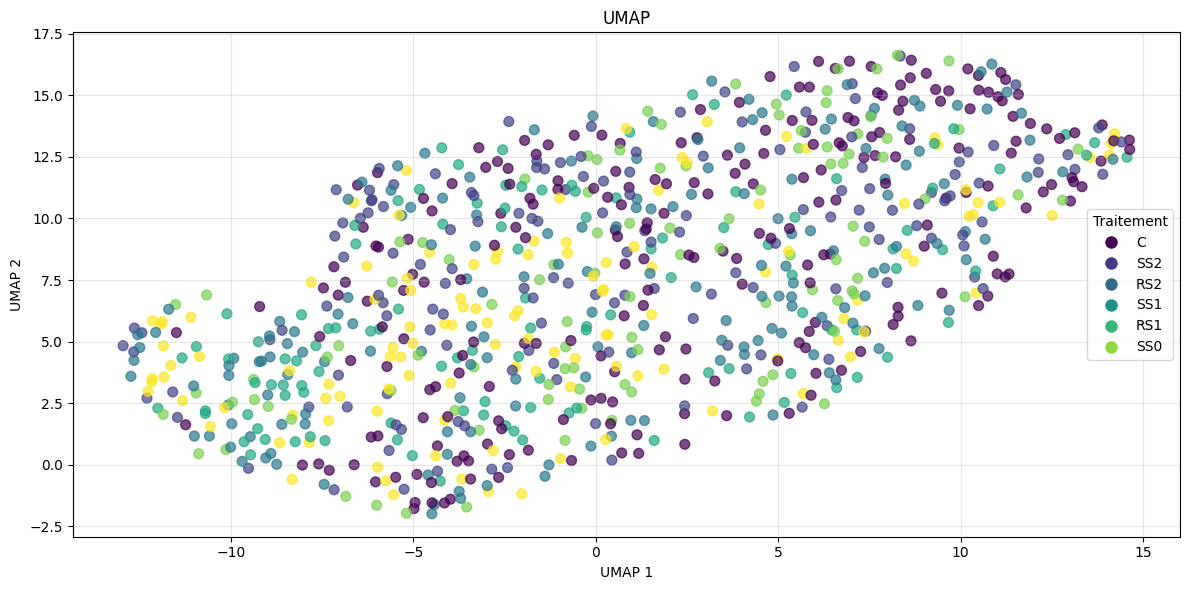

In [31]:
title_base = "Projection par t-SNE des spectres NIRS des feuilles btx"
plot_tsne(btx_leaf_data,'Traitement', title=title_base + ' - Traitement')

# Plot UMAP
plot_UMAP_default(btx_leaf_data,X_umap,'Traitement',"Proj")


In [34]:

# Prepare spectral matrix and scale
X = btx_grain_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)


# Calculer une perplexity adaptée
n_samples = len(btx_grain_data)
recommended_perplexity = min(30, max(5, n_samples // 3))

# run t-SNE avec paramètres adaptés
tsne = TSNE(n_components=2, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

print(f"\nt-SNE shape : {X_tsne.shape}")


# UMAP avec min_dist élevé pour mieux espacer les points
reducer = umap.UMAP(random_state=42, min_dist=0.5, spread=1.5, n_neighbors=15)
X_umap = reducer.fit_transform(X_scaled)



[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 236 samples in 0.004s...
[t-SNE] Computed neighbors for 236 samples in 0.013s...
[t-SNE] Computed conditional probabilities for sample 236 / 236
[t-SNE] Mean sigma: 15.291541
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.203106
[t-SNE] KL divergence after 1100 iterations: 0.360015

t-SNE shape : (236, 2)


/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


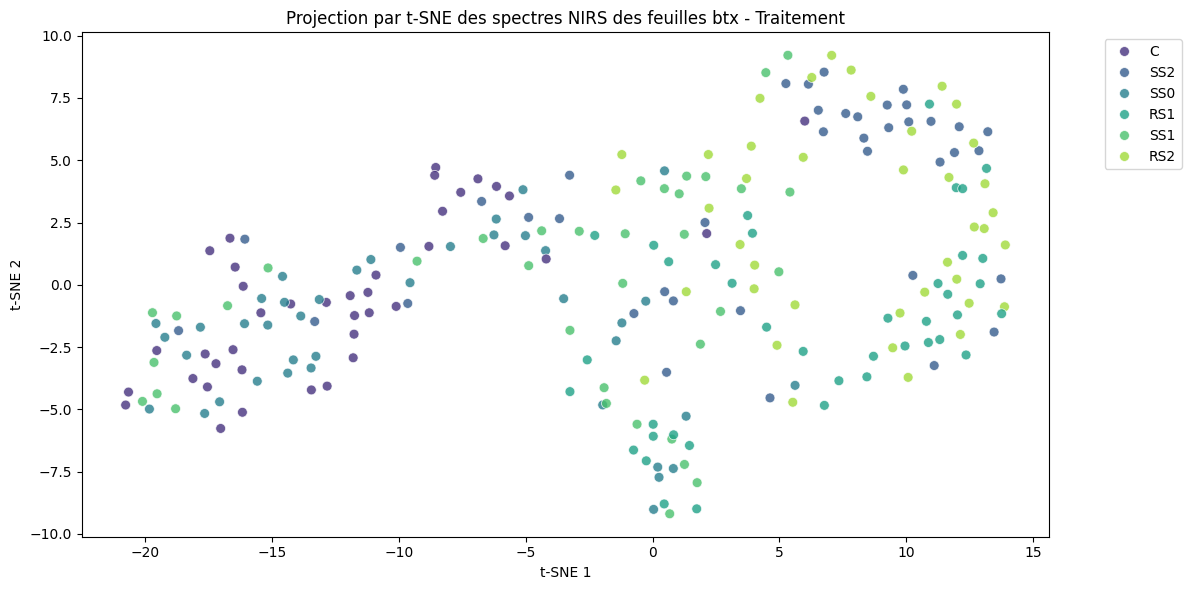

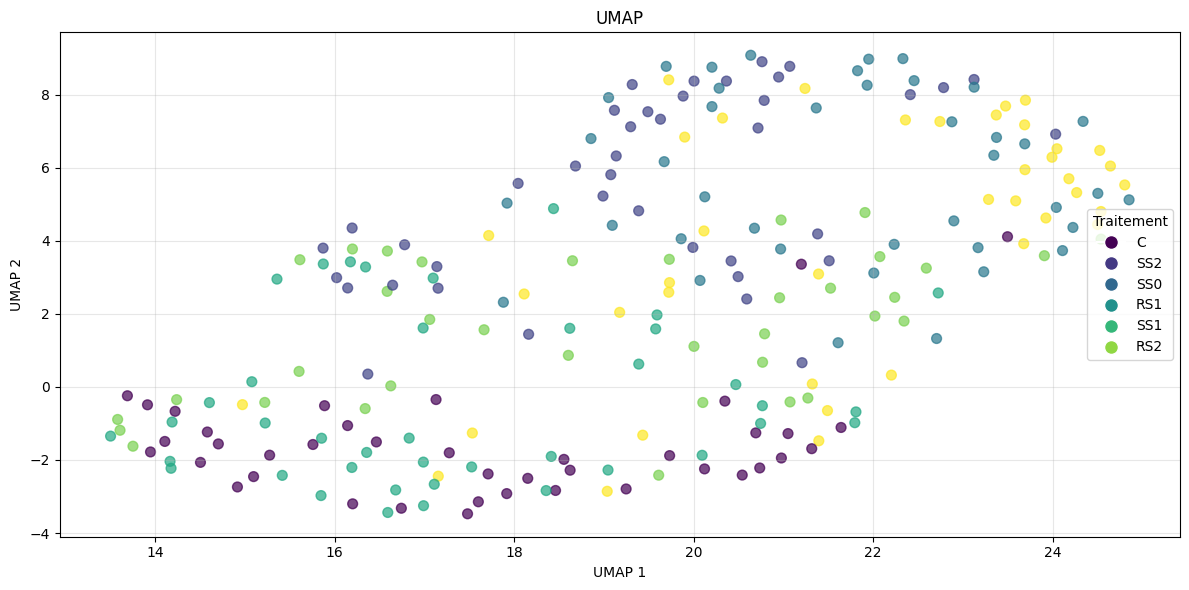

In [35]:
title_base = "Projection par t-SNE des spectres NIRS des feuilles btx"
plot_tsne(btx_grain_data,'Traitement', title=title_base + ' - Traitement')

# Plot UMAP
plot_UMAP_default(btx_grain_data,X_umap,'Traitement',"Proj")

In [36]:

# Prepare spectral matrix and scale
X = macia_grain_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)


# Calculer une perplexity adaptée
n_samples = len(macia_grain_data)
recommended_perplexity = min(30, max(5, n_samples // 3))

# run t-SNE avec paramètres adaptés
tsne = TSNE(n_components=2, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

print(f"\nt-SNE shape : {X_tsne.shape}")


# UMAP avec min_dist élevé pour mieux espacer les points
reducer = umap.UMAP(random_state=42, min_dist=1, spread=2, n_neighbors=15)
X_umap = reducer.fit_transform(X_scaled)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 240 samples in 0.003s...
[t-SNE] Computed neighbors for 240 samples in 0.011s...
[t-SNE] Computed conditional probabilities for sample 240 / 240
[t-SNE] Mean sigma: 14.148323
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.793983
[t-SNE] KL divergence after 1200 iterations: 0.354801

t-SNE shape : (240, 2)


/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


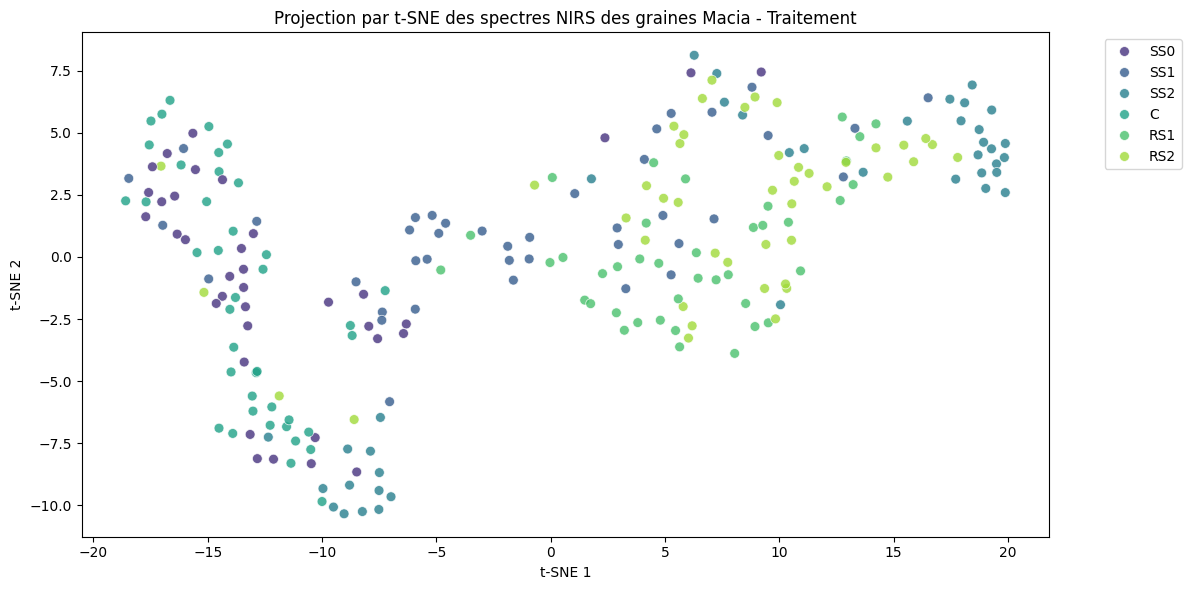

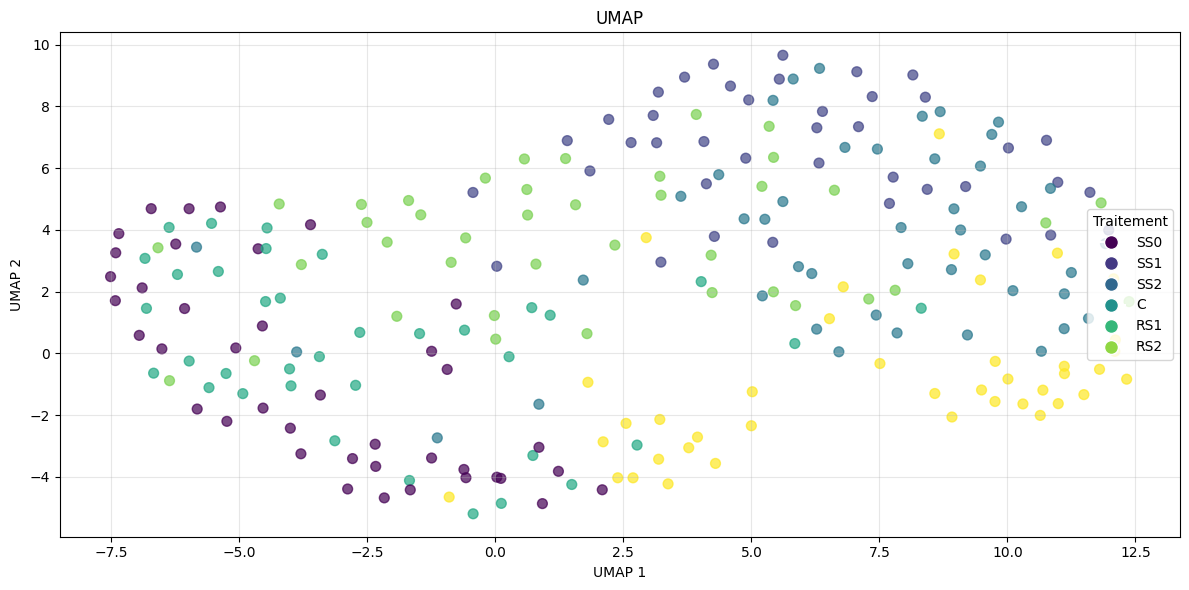

In [37]:
title_base = "Projection par t-SNE des spectres NIRS des graines Macia"
plot_tsne(macia_grain_data,'Traitement', title=title_base + ' - Traitement')

# Plot UMAP
plot_UMAP_default(macia_grain_data,X_umap,'Traitement',"Proj")

In [38]:
# ==== Quantifier la séparabilité des groupes =====
from scipy.spatial.distance import pdist, squareform

X = macia_leaf_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)
traitements = macia_leaf_data['Traitement'].values

# Calculer distances euclidiennes
distances = squareform(pdist(X_scaled, metric='euclidean'))

# Pour chaque traitement, calculer distances intra et inter-groupes
traitements_uniques = np.unique(traitements)
print("Analyse des distances (données standardisées) :\n")

distances_intra = []
distances_inter = []

for trait in traitements_uniques:
    mask = traitements == trait
    n_samples_trait = mask.sum()
    
    if n_samples_trait < 2:
        continue
    
    # Distances intra-groupe (entre échantillons du même traitement)
    indices = np.where(mask)[0]
    dist_intra = distances[np.ix_(indices, indices)]
    dist_intra = dist_intra[np.triu_indices_from(dist_intra, k=1)]  # Matrice triangulaire sup
    
    # Distances inter-groupes (entre ce traitement et les autres)
    indices_autres = np.where(~mask)[0]
    if len(indices_autres) > 0:
        dist_inter = distances[np.ix_(indices, indices_autres)]
        print(f"    - Ratio inter/intra : {dist_inter.mean() / dist_intra.mean():.2f}")
        
        distances_intra.extend(dist_intra)
        distances_inter.extend(dist_inter.flatten())

print("   < 1.2 : Groupes très chevauchés → difficile à séparer")
print("   1.2-2.0 : Séparation modérée → nécessite algorithme non-linéaire")
print("   > 2.0 : Groupes bien séparés → devrait clustériser facilement")


Analyse des distances (données standardisées) :

    - Ratio inter/intra : 1.38
    - Ratio inter/intra : 0.88
    - Ratio inter/intra : 0.91
    - Ratio inter/intra : 1.14
    - Ratio inter/intra : 1.02
    - Ratio inter/intra : 0.99
   < 1.2 : Groupes très chevauchés → difficile à séparer
   1.2-2.0 : Séparation modérée → nécessite algorithme non-linéaire
   > 2.0 : Groupes bien séparés → devrait clustériser facilement


Moralité : On a des groupes tres chevaucher qui est difficile à distinguer. Cependant on constate sur les graines qu'il semble y avoir des superpositions de groupes sur les graines la suite de nos projection vont se porter sur cela.

On poursuit alors en essayant de comparer les projections entre t-SNE et UMAP

/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 240 samples in 0.005s...
[t-SNE] Computed neighbors for 240 samples in 0.011s...
[t-SNE] Computed conditional probabilities for sample 240 / 240
[t-SNE] Mean sigma: 14.148323
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.793976
[t-SNE] KL divergence after 1200 iterations: 0.354801


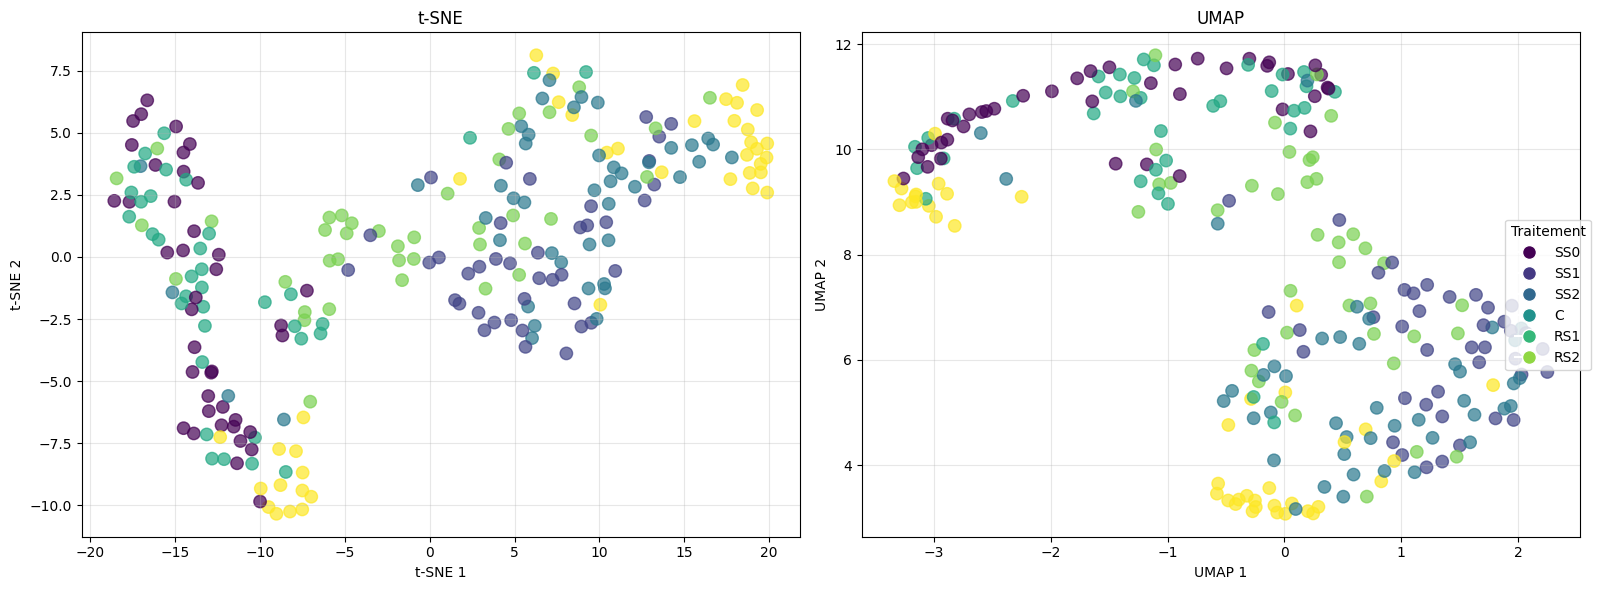

In [39]:

X = macia_grain_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)
    
# UMAP avec paramètres par défaut
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# t-SNE avec paramètres par dégaut
tsne = TSNE(n_components=2, 
            perplexity=30, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)
    
# Comparaison t-SNE vs UMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#récupérations des différents valeur de traitement
colors = macia_grain_data['Traitement'].astype('category').cat.codes
    
# t-SNE
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, cmap='viridis', s=80, alpha=0.7)
axes[0].set_title('t-SNE')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].grid(alpha=0.3)
    
# UMAP
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, cmap='viridis', s=80, alpha=0.7)
axes[1].set_title('UMAP')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].grid(alpha=0.3)
    
labels_unique = macia_grain_data['Traitement'].unique()
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor=plt.cm.viridis(i/len(labels_unique)), 
                          markersize=10, label=lbl) 
              for i, lbl in enumerate(labels_unique)]
fig.legend(handles=handles, loc='center right', title='Traitement')
    
plt.tight_layout()
plt.show()
    


Le résultat semble souvent présenter des clusters superposé mais on ne peut pas vraiment en dire plus, les résultats sont vraiment tres similaire mais on peut se poser la question d'augementer la dimension de projection

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 236 samples in 0.005s...
[t-SNE] Computed neighbors for 236 samples in 0.013s...
[t-SNE] Computed conditional probabilities for sample 236 / 236
[t-SNE] Mean sigma: 15.291541
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.267281
[t-SNE] KL divergence after 650 iterations: 0.243662


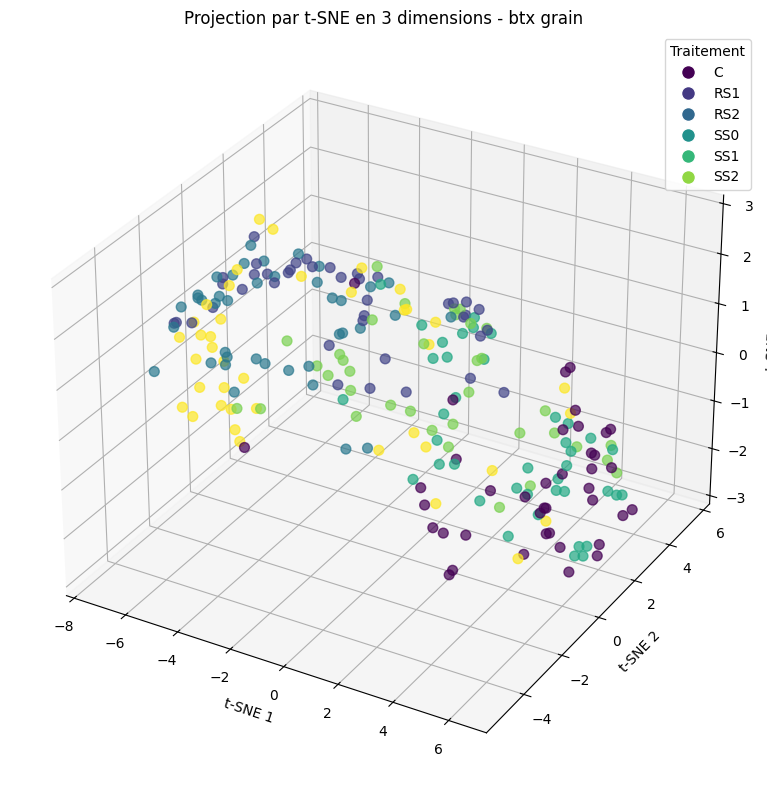

In [41]:

# Prepare spectral matrix and scale
X = btx_grain_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)

# Calculer une perplexity adaptée
n_samples = len(btx_grain_data)
recommended_perplexity = min(30, max(5, n_samples // 3))

# run t-SNE en 3 dimensions
tsne = TSNE(n_components=3, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

# Plot 3D manuel
categories = btx_grain_data['Traitement'].astype('category')
colors = categories.cat.codes
labels_unique = categories.cat.categories

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2],
           c=colors, cmap='viridis', s=50, alpha=0.7)
ax.set_title("Projection par t-SNE en 3 dimensions - btx grain")
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=plt.cm.viridis(i / len(labels_unique)),
                      markersize=10, label=lbl)
           for i, lbl in enumerate(labels_unique)]
ax.legend(handles=handles, title='Traitement')
plt.tight_layout()
plt.show()
